<a href="https://colab.research.google.com/github/Pn0529/cardiosafe/blob/main/CardioSafeDataPreprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
df = pd.read_csv("/content/framinho heart study dataset.zip")


In [ ]:
print(df["TenYearCHD"].value_counts())

TenYearCHD
0    3596
1     644
Name: count, dtype: int64


In [ ]:
df = df.drop_duplicates()

In [ ]:
for col in df.columns:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
df = df.loc[:, df.nunique() > 1]

In [ ]:
df["pulsePressure"] = df["sysBP"] - df["diaBP"]

In [ ]:
df.to_csv("framingham_preprocessed.csv", index=False)

from google.colab import files
files.download("framingham_preprocessed.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print(df["BPMeds"].unique())
print(df["prevalentStroke"].unique())
print(df[["BPMeds","prevalentStroke"]].nunique())

[0. 1.]
[0 1]
BPMeds             2
prevalentStroke    2
dtype: int64


In [ ]:
print(corr["TenYearCHD"].sort_values())

education         -0.053570
currentSmoker      0.019448
heartRate          0.022851
cigsPerDay         0.058729
prevalentStroke    0.061823
BMI                0.074326
totChol            0.081749
BPMeds             0.086448
male               0.088374
diabetes           0.097344
glucose            0.121319
diaBP              0.145112
prevalentHyp       0.177458
pulsePressure      0.206848
sysBP              0.216374
age                0.225408
TenYearCHD         1.000000
Name: TenYearCHD, dtype: float64


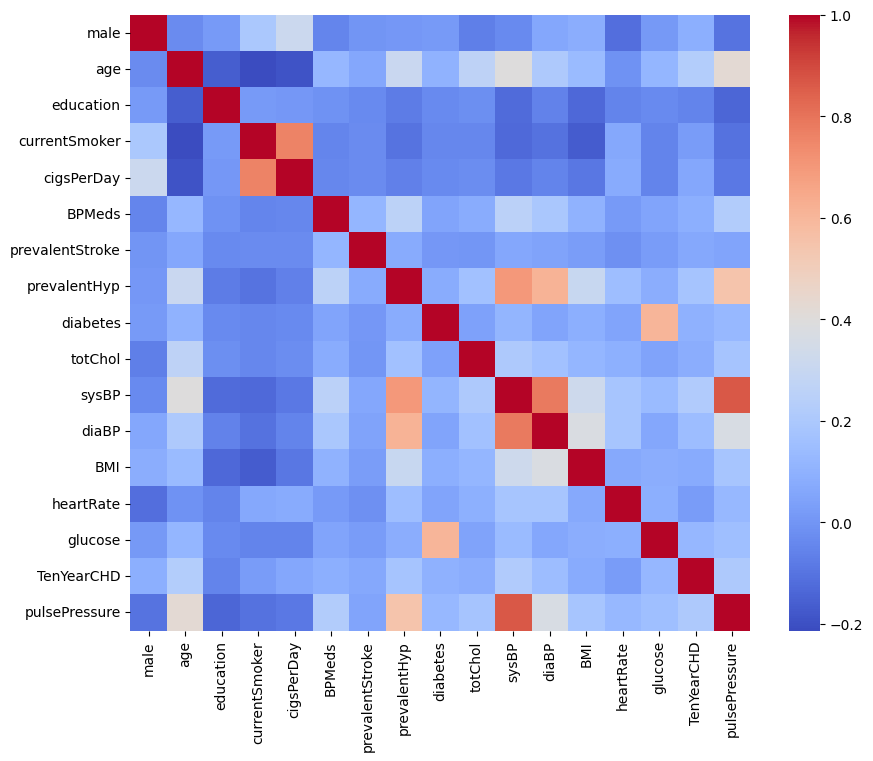

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=False, cmap="coolwarm")
plt.show()